# Module 6 — Fuzzy Inference System (Mamdani)

## Linguistic Variables

### Input 1 — Brightness (normalised mean intensity)
| Label | MF type | Parameters |
|---|---|---|
| Dark | Trapezoid | [0, 0, 0.25, 0.45] |
| Medium | Triangle | [0.3, 0.5, 0.7] |
| Bright | Trapezoid | [0.55, 0.75, 1.0, 1.0] |

### Input 2 — Contrast (normalised std deviation)
| Label | MF type | Parameters |
|---|---|---|
| Low | Trapezoid | [0, 0, 0.2, 0.4] |
| Medium | Triangle | [0.3, 0.5, 0.7] |
| High | Trapezoid | [0.6, 0.8, 1.0, 1.0] |

### Output — Adjustment level ∈ [-1, 1]
| Label | MF type | Parameters |
|---|---|---|
| Decrease | Triangle | [-1.0, -0.5, 0.0] |
| No change | Triangle | [-0.2, 0.0, 0.2] |
| Increase | Triangle | [0.0, 0.5, 1.0] |

**Inference:** Mamdani (AND = min, aggregation = max)  
**Defuzzification:** Centroid method


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from config import Config

print("Imports successful.")

Imports successful.


In [3]:
# Membership function primitives

def triangular_mf(x: float, a: float, b: float, c: float) -> float:
    """
    Triangular MF.  Peak at b, zero at a and c.
    """
    if x <= a or x >= c:
        return 0.0
    if x <= b:
        return (x - a) / (b - a + 1e-8)
    return (c - x) / (c - b + 1e-8)


def trapezoidal_mf(x: float, a: float, b: float, c: float, d: float) -> float:
    """
    Trapezoidal MF.  Flat top between b and c.
    """
    if x <= a or x >= d:
        return 0.0
    if b <= x <= c:
        return 1.0
    if x < b:
        return (x - a) / (b - a + 1e-8)
    return (d - x) / (d - c + 1e-8)


print("MF primitives defined.")

MF primitives defined.


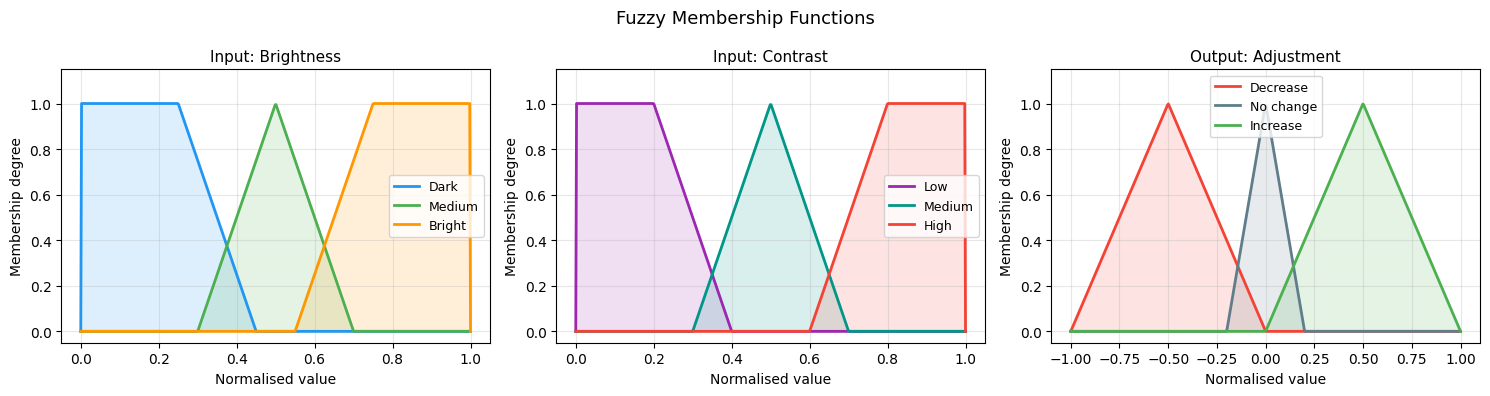

 Saved fuzzy_membership_functions.png


In [5]:
#  Visualise membership functions

x_vals = np.linspace(0, 1, 500)

def plot_mf_set(ax, x, mf_dict, title, colors):
    for (label, values), color in zip(mf_dict.items(), colors):
        ax.plot(x, values, label=label, color=color, linewidth=2)
        ax.fill_between(x, values, alpha=0.15, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Normalised value")
    ax.set_ylabel("Membership degree")
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Compute MF curves over the universe
brightness_mfs = {
    "Dark":   [trapezoidal_mf(x, 0.0, 0.0, 0.25, 0.45) for x in x_vals],
    "Medium": [triangular_mf(x, 0.3, 0.5, 0.7)         for x in x_vals],
    "Bright": [trapezoidal_mf(x, 0.55, 0.75, 1.0, 1.0) for x in x_vals],
}

contrast_mfs = {
    "Low":    [trapezoidal_mf(x, 0.0, 0.0, 0.2, 0.4) for x in x_vals],
    "Medium": [triangular_mf(x, 0.3, 0.5, 0.7)       for x in x_vals],
    "High":   [trapezoidal_mf(x, 0.6, 0.8, 1.0, 1.0) for x in x_vals],
}

x_out = np.linspace(-1, 1, 500)
adjustment_mfs = {
    "Decrease":  [triangular_mf(x, -1.0, -0.5,  0.0) for x in x_out],
    "No change": [triangular_mf(x, -0.2,  0.0,  0.2) for x in x_out],
    "Increase":  [triangular_mf(x,  0.0,  0.5,  1.0) for x in x_out],
}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
plot_mf_set(ax1, x_vals, brightness_mfs,  "Input: Brightness",   ["#2196F3", "#4CAF50", "#FF9800"])
plot_mf_set(ax2, x_vals, contrast_mfs,    "Input: Contrast",     ["#9C27B0", "#009688", "#F44336"])
plot_mf_set(ax3, x_out,  adjustment_mfs,  "Output: Adjustment",  ["#F44336", "#607D8B", "#4CAF50"])

plt.suptitle("Fuzzy Membership Functions", fontsize=13)
plt.tight_layout()
plt.savefig("fuzzy_membership_functions.png", dpi=120)
plt.show()
print(" Saved fuzzy_membership_functions.png")

In [7]:
#  Input fuzzification functions 

def brightness_mf(brightness: float) -> dict:
    """Map normalised brightness value → membership degrees."""
    return {
        "dark":   trapezoidal_mf(brightness, 0.0, 0.0, 0.25, 0.45),
        "medium": triangular_mf( brightness, 0.3, 0.5, 0.7),
        "bright": trapezoidal_mf(brightness, 0.55, 0.75, 1.0, 1.0),
    }


def contrast_mf(contrast: float) -> dict:
    """Map normalised contrast value → membership degrees."""
    return {
        "low":    trapezoidal_mf(contrast, 0.0, 0.0, 0.2, 0.4),
        "medium": triangular_mf( contrast, 0.3, 0.5, 0.7),
        "high":   trapezoidal_mf(contrast, 0.6, 0.8, 1.0, 1.0),
    }


def adjustment_mf_vec(x_vals: np.ndarray, label: str) -> np.ndarray:
    """Vectorised output MF over an array of universe points."""
    params = {
        "decrease":  (-1.0, -0.5, 0.0),
        "no_change": (-0.2,  0.0, 0.2),
        "increase":  ( 0.0,  0.5, 1.0),
    }
    a, b, c = params[label]
    return np.array([triangular_mf(x, a, b, c) for x in x_vals], dtype=np.float32)


print("Fuzzification functions defined.")

Fuzzification functions defined.


In [10]:
#  Rule base 

RULE_BASE = [
    # (brightness_label, contrast_label, output_label, weight)
    ("dark",   "low",    "increase",  1.0),   # very under-exposed → strong boost
    ("dark",   "medium", "increase",  0.9),
    ("dark",   "high",   "increase",  0.7),   # dark but already contrasty
    ("medium", "low",    "increase",  0.6),   # normal brightness, flat → boost contrast
    ("medium", "medium", "no_change", 1.0),   # already good → leave alone
    ("medium", "high",   "decrease",  0.5),
    ("bright", "low",    "no_change", 0.5),   # bright but flat
    ("bright", "medium", "decrease",  0.9),
    ("bright", "high",   "decrease",  1.0),   # over-exposed → reduce
]

print(f"Rule base loaded: {len(RULE_BASE)} rules")
print("\nRule base:")
for r in RULE_BASE:
    print(f"  IF brightness={r[0]:6s} AND contrast={r[1]:6s}  "
          f"→ {r[2]:10s}  [weight={r[3]}]")

Rule base loaded: 9 rules

Rule base:
  IF brightness=dark   AND contrast=low     → increase    [weight=1.0]
  IF brightness=dark   AND contrast=medium  → increase    [weight=0.9]
  IF brightness=dark   AND contrast=high    → increase    [weight=0.7]
  IF brightness=medium AND contrast=low     → increase    [weight=0.6]
  IF brightness=medium AND contrast=medium  → no_change   [weight=1.0]
  IF brightness=medium AND contrast=high    → decrease    [weight=0.5]
  IF brightness=bright AND contrast=low     → no_change   [weight=0.5]
  IF brightness=bright AND contrast=medium  → decrease    [weight=0.9]
  IF brightness=bright AND contrast=high    → decrease    [weight=1.0]


In [14]:
#Mamdani inference engine 

class FuzzyEnhancementSystem:
   

    def __init__(self, resolution: int = 500):
        lo, hi     = Config.ADJUSTMENT_UNIVERSE
        self.x_out = np.linspace(lo, hi, resolution)

    def infer(self, brightness: float, contrast: float) -> dict:
       
        # Step 1: Fuzzify inputs
        b_mems = brightness_mf(brightness)
        c_mems = contrast_mf(contrast)

        # Step 2-4: Apply rules, implication, aggregation
        aggregated   = np.zeros_like(self.x_out)
        active_rules = []

        for (b_lbl, c_lbl, out_lbl, weight) in RULE_BASE:
            # AND = min; multiply by rule weight
            strength = min(b_mems[b_lbl], c_mems[c_lbl]) * weight

            if strength < 1e-4:
                continue

            # Implication: clip output MF at firing strength
            out_mf  = adjustment_mf_vec(self.x_out, out_lbl)
            clipped = np.minimum(out_mf, strength)

            # Aggregation: max across all rules
            aggregated = np.maximum(aggregated, clipped)

            active_rules.append({
                "rule":     f"IF {b_lbl} AND {c_lbl} → {out_lbl}",
                "strength": round(strength, 4),
            })

        # Step 5: Defuzzification — centroid (centre of mass)
        denom = np.sum(aggregated)
        if denom < 1e-8:
            crisp = 0.0   # no rules fired → no adjustment
        else:
            crisp = float(np.sum(self.x_out * aggregated) / denom)

        return {
            "adjustment":   crisp,
            "active_rules": active_rules,
            "aggregated":   aggregated,
        }

    def get_universe(self):
        return self.x_out


print("FuzzyEnhancementSystem class defined.")

FuzzyEnhancementSystem class defined.


In [15]:
# Demo: run inference for different image conditions

fis        = FuzzyEnhancementSystem()
test_cases = [
    ("Dark + Low contrast",    0.15, 0.10),
    ("Dark + High contrast",   0.20, 0.75),
    ("Normal + Normal",        0.50, 0.50),
    ("Bright + High contrast", 0.85, 0.80),
]

print(f"{'Condition':<30} {'Brightness':>10} {'Contrast':>10} {'Adjustment':>12}")
print("-" * 65)
for name, bv, cv in test_cases:
    result = fis.infer(bv, cv)
    print(f"{name:<30} {bv:>10.2f} {cv:>10.2f} {result['adjustment']:>12.4f}")

Condition                      Brightness   Contrast   Adjustment
-----------------------------------------------------------------
Dark + Low contrast                  0.15       0.10       0.5000
Dark + High contrast                 0.20       0.75       0.5000
Normal + Normal                      0.50       0.50      -0.0000
Bright + High contrast               0.85       0.80      -0.5000


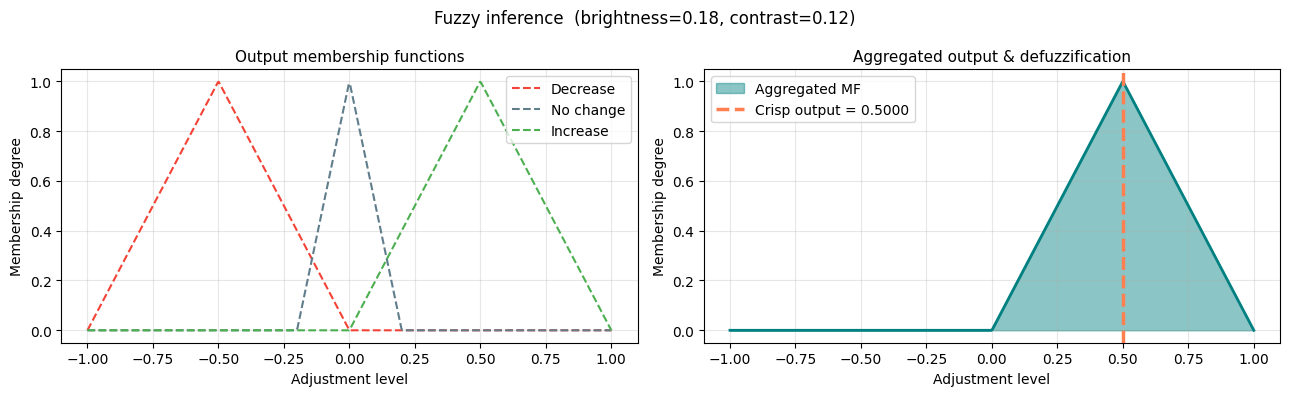


  Crisp adjustment : 0.5000
  Active rules (1) :
    IF dark AND low → increase  [str=1.0]


In [16]:
#Visualise fuzzy output MF for a specific condition 

def plot_fuzzy_inference(fis, brightness, contrast):
    result    = fis.infer(brightness, contrast)
    x_out     = fis.get_universe()
    agg       = result["aggregated"]
    crisp     = result["adjustment"]

    # Also overlay the three output MFs for reference
    dec  = adjustment_mf_vec(x_out, "decrease")
    nc   = adjustment_mf_vec(x_out, "no_change")
    inc  = adjustment_mf_vec(x_out, "increase")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Left: individual output MFs
    ax1.plot(x_out, dec, "--", color="#F44336", label="Decrease",  linewidth=1.5)
    ax1.plot(x_out, nc,  "--", color="#607D8B", label="No change", linewidth=1.5)
    ax1.plot(x_out, inc, "--", color="#4CAF50", label="Increase",  linewidth=1.5)
    ax1.set_title("Output membership functions", fontsize=11)
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_xlabel("Adjustment level")
    ax1.set_ylabel("Membership degree")

    # Right: aggregated MF + centroid
    ax2.fill_between(x_out, agg, alpha=0.45, color="teal", label="Aggregated MF")
    ax2.plot(x_out, agg, color="teal", linewidth=2)
    ax2.axvline(crisp, color="coral", linewidth=2.5, linestyle="--",
                label=f"Crisp output = {crisp:.4f}")
    ax2.set_title(f"Aggregated output & defuzzification", fontsize=11)
    ax2.set_xlabel("Adjustment level")
    ax2.set_ylabel("Membership degree")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(f"Fuzzy inference  (brightness={brightness:.2f}, contrast={contrast:.2f})",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig("fuzzy_output_mf.png", dpi=120)
    plt.show()

    print(f"\n  Crisp adjustment : {crisp:.4f}")
    print(f"  Active rules ({len(result['active_rules'])}) :")
    for r in result["active_rules"]:
        print(f"    {r['rule']}  [str={r['strength']}]")


# Demo: dark, low-contrast image
plot_fuzzy_inference(fis, brightness=0.18, contrast=0.12)

In [34]:
# Save module to disk 
import inspect

source = """
import numpy as np
from config import Config


# ── Membership Functions ─────────────────────────────

def triangular_mf(x, a, b, c):
    return max(min((x - a) / (b - a + 1e-6),
                   (c - x) / (c - b + 1e-6)), 0.0)


def trapezoidal_mf(x, a, b, c, d):
    return max(min((x - a) / (b - a + 1e-6),
                   1.0,
                   (d - x) / (d - c + 1e-6)), 0.0)


def brightness_mf(brightness: float) -> dict:
    return {
        "dark":   trapezoidal_mf(brightness, 0.0, 0.0, 0.25, 0.45),
        "medium": triangular_mf(brightness, 0.3, 0.5, 0.7),
        "bright": trapezoidal_mf(brightness, 0.55, 0.75, 1.0, 1.0),
    }


def contrast_mf(contrast: float) -> dict:
    return {
        "low":    trapezoidal_mf(contrast, 0.0, 0.0, 0.2, 0.4),
        "medium": triangular_mf(contrast, 0.3, 0.5, 0.7),
        "high":   trapezoidal_mf(contrast, 0.6, 0.8, 1.0, 1.0),
    }


def adjustment_mf_vec(x_vals: np.ndarray, label: str) -> np.ndarray:
    params = {
        "decrease":  (-1.0, -0.5, 0.0),
        "no_change": (-0.2,  0.0, 0.2),
        "increase":  ( 0.0,  0.5, 1.0),
    }
    a, b, c = params[label]
    return np.array([triangular_mf(x, a, b, c) for x in x_vals], dtype=np.float32)


RULE_BASE = [
    ("dark",   "low",    "increase",  1.0),
    ("dark",   "medium", "increase",  0.9),
    ("dark",   "high",   "increase",  0.7),
    ("medium", "low",    "increase",  0.6),
    ("medium", "medium", "no_change", 1.0),
    ("medium", "high",   "decrease",  0.5),
    ("bright", "low",    "no_change", 0.5),
    ("bright", "medium", "decrease",  0.9),
    ("bright", "high",   "decrease",  1.0),   
]


class FuzzyEnhancementSystem:

    def __init__(self, resolution: int = 500):
        lo, hi     = Config.ADJUSTMENT_UNIVERSE
        self.x_out = np.linspace(lo, hi, resolution)

    def infer(self, brightness: float, contrast: float) -> dict:

        b_mems = brightness_mf(brightness)
        c_mems = contrast_mf(contrast)

        aggregated   = np.zeros_like(self.x_out)
        active_rules = []

        for (b_lbl, c_lbl, out_lbl, weight) in RULE_BASE:

            strength = min(b_mems[b_lbl], c_mems[c_lbl]) * weight

            if strength < 1e-4:
                continue

            out_mf  = adjustment_mf_vec(self.x_out, out_lbl)
            clipped = np.minimum(out_mf, strength)

            aggregated = np.maximum(aggregated, clipped)

            active_rules.append({
                "rule": "IF {b_lbl} AND {c_lbl} -> {out_lbl}".format(
                    b_lbl=b_lbl, c_lbl=c_lbl, out_lbl=out_lbl),
                "strength": round(strength, 4),
            })

        denom = np.sum(aggregated)
        if denom < 1e-8:
            crisp = 0.0
        else:
            crisp = float(np.sum(self.x_out * aggregated) / denom)

        return {
            "adjustment":   crisp,
            "active_rules": active_rules,
            "aggregated":   aggregated,
        }

    def get_universe(self):
        return self.x_out
"""

with open("fuzzy_system.py", "w", encoding="utf-8") as f:
    f.write(source)

print(" fuzzy_system.py written to disk.")

 fuzzy_system.py written to disk.
